In [17]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import DetCurveDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
import math
import scipy as sp
import sys
import torch
sys.path.append('../')
import scipy.io as sio
import mat73
import pandas as pd
import numpy as np
from alive_progress import alive_bar
from utils.my_classes import dataset 
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report,accuracy_score
from sklearn.model_selection import PredefinedSplit
from sklearn.model_selection import  GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle
import utils.my_classes as my_classes
import utils.my_functions as my_functions
import utils
from sklearn.metrics import roc_auc_score
from utils.my_functions import timing
import sklearn.metrics

def check_performance(file_path_model,model_name,test_dataset,number_after_point = 2):
   
    with open(file_path_model, 'rb') as file:
        model = pickle.load(file)
        
        pred = model.predict(test_dataset.data)

        pos_pred_proba  = model.predict_proba(test_dataset.data)[:,1]

        cm = confusion_matrix(test_dataset.sex, pred, labels=model.classes_,normalize=None)

        formatted_cm = np.round(cm, decimals=number_after_point)

        # print confusion matrix - XGB
        disp = ConfusionMatrixDisplay(confusion_matrix=formatted_cm,
                                        display_labels=["Female","Male"])
        disp.plot()
        plt.show()
        cm = confusion_matrix(test_dataset.sex, pred, labels=model.classes_,normalize='true')
        
        formatted_cm = np.round(cm, decimals=number_after_point)

        # print confusion matrix - XGB
        disp = ConfusionMatrixDisplay(confusion_matrix=formatted_cm,
                                        display_labels=["Female","Male"])
        disp.plot()
        plt.show()
        #print ROC curve - XGB
        fpr, tpr, _ = metrics.roc_curve(test_dataset.sex, pos_pred_proba) 
        auc = metrics.roc_auc_score(test_dataset.sex, pos_pred_proba)

        #create ROC curve - XGB
        plt.figure()
        plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
        plt.ylabel('True Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.legend(loc=4)
        plt.show()

        print("Test = Accuracy:",accuracy_score(test_dataset.sex, pred))
        print("Test - AUC:",roc_auc_score(test_dataset.sex,pos_pred_proba))
        print("Test - Balanced Accuracy:",metrics.balanced_accuracy_score(test_dataset.sex, pred))
        
        wrong_preds = np.array([1 if pred_element == label else 0 for pred_element, label in zip(pred, test_dataset.sex) ])
        print(f"All - {model_name} Classifier - wrong predictions:")
        print("------------------------")
        print(test_dataset.attack_logical[wrong_preds == 0].value_counts()) #wrong prediction by attack type
        print("------------------------")
        print(test_dataset.attack_logical[wrong_preds == 1].value_counts()) #correct prediction by attack type
        print("------------------------")

        ## wrong predection by attacks with precents:
        wrong_pred_precent = []
        indexex_attacks = []
        for index_attack in test_dataset.attack_logical[wrong_preds == 0].unique():  
            indexex_attacks.append(index_attack)
            wrong_pred_precent.append(test_dataset.attack_logical[wrong_preds == 0].value_counts()[index_attack]/test_dataset.attack_logical.value_counts()[index_attack])
        
        if wrong_pred_precent != []:
            sorted_lists = sorted(zip(wrong_pred_precent,indexex_attacks),reverse = True)
            sorted_list1, sorted_list2 = zip(*sorted_lists)

            for i in range(len(sorted_list1)): 
                print(f"wrong predictions by attack type:{sorted_list2[i]} - {sorted_list1[i]:.3f}% from total {sorted_list2[i]} values") 
        else:
            print("No wrong predictions")

In [18]:
from ASV_utils.data_loading import *

models_folder = "ECAPA_TDNN/inference_models/"

data_path_all = "Data/male_vs_female_models_16_bits_ver2/none/all/"


embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,chosen_labels_1_1_is_spoofed,chosen_labels_2_1_is_spoofed,chosen_labels_3_1_is_spoofed,chosen_labels_numeric_1_1,chosen_labels_numeric_2_1,chosen_labels_numeric_3_1,chosen_labels_1_1_attack_logical,chosen_labels_2_1_attack_logical,chosen_labels_3_1_attack_logical,chosen_labels_1_1_name,chosen_labels_2_1_name,chosen_labels_3_1_name,chosen_labels_1_1_speaker_id,chosen_labels_2_1_speaker_id,chosen_labels_3_1_speaker_id,chosen_labels_1_1_sex,chosen_labels_2_1_sex,chosen_labels_3_1_sex  = load_data_all(data_path_all)



In [19]:
import utils.my_functions as my_functions
columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)


embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]

In [20]:
from sklearn.preprocessing import StandardScaler
import re

your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract gammatone, gammatone_inv, channel number, and distance metric
    match = re.search(r'filter-(gammatone(?:_inv)?)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        gammatone = match.group(1)
        channel = int(match.group(2))
        distance_metric = match.group(3)

        # Assign a higher priority to distance_order, a medium priority to channels,
        # and lower priority to 'gammatone' and 'gammatone_inv'
        return (distance_metrics.index(distance_metric), channel, gammatone)

    else:
        # If the regex doesn't match, return the original item to maintain its position
        return (999, 999, "")

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    

embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]



In [21]:
train_dataset = dataset(data = embedded_groups_1_1 , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1, # define the train set
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id, sex = chosen_labels_1_1_sex ,data_transform = None , labels_transform = None);

validation_dataset = dataset(data = embedded_groups_1_2 , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1, # define the validation set
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = chosen_labels_2_1_sex ,data_transform = None , labels_transform = None);

test_dataset = dataset(data = embedded_groups_1_3 , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1, # define the test set
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id,  sex = chosen_labels_3_1_sex ,data_transform = None , labels_transform = None);

In [22]:
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(train_dataset.data)
mean_features = scaler.mean_
std_features = scaler.scale_
train_dataset.data = scaler.transform(train_dataset.data)
validation_dataset.data = scaler.transform(validation_dataset.data)
test_dataset.data = scaler.transform(test_dataset.data)


In [23]:
train_dataset.attack_logical = pd.Series([elem[0] for elem in train_dataset.attack_logical])
validation_dataset.attack_logical = pd.Series([elem[0] for elem in validation_dataset.attack_logical])
test_dataset.attack_logical = pd.Series([elem[0] for elem in test_dataset.attack_logical])

In [24]:
train_dataset.sex[train_dataset.sex == 'male'] = 1
train_dataset.sex[train_dataset.sex == 'female'] = 0

validation_dataset.sex[validation_dataset.sex == 'male'] = 1
validation_dataset.sex[validation_dataset.sex == 'female'] = 0

test_dataset.sex[test_dataset.sex == 'male'] = 1
test_dataset.sex[test_dataset.sex == 'female'] = 0


train_dataset.sex = train_dataset.sex.astype('int')
validation_dataset.sex = validation_dataset.sex.astype('int')
test_dataset.sex = test_dataset.sex.astype('int')

## Performance on Development Set

In [25]:
models_path = "./ML_codes/new_normalize_all_female_and_male/female_vs_male_histograms/"

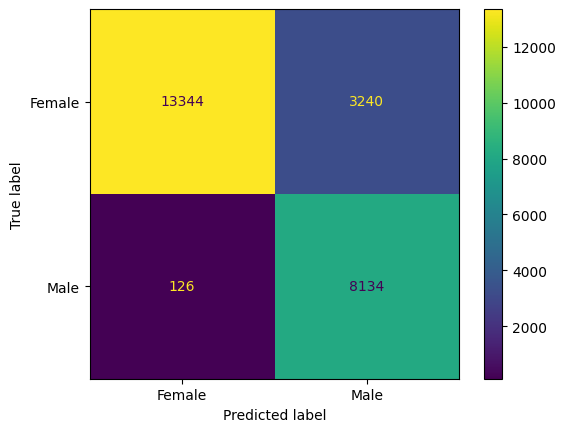

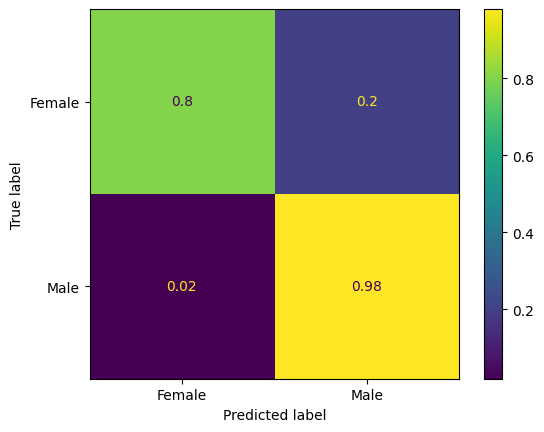

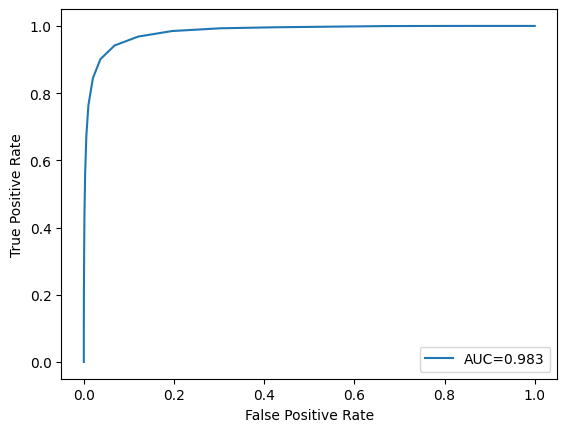

Test = Accuracy: 0.8645145709225568
Test - AUC: 0.982853758516333
Test - Balanced Accuracy: 0.8946883661605631
All - Balanced Random Forest Classifier - wrong predictions:
------------------------
A03     831
A05     727
A01     440
A04     420
none    337
A02     308
A06     303
Name: count, dtype: int64
------------------------
A06     3413
A02     3408
A04     3296
A01     3276
A05     2989
A03     2885
none    2211
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A03 - 0.224% from total A03 values
wrong predictions by attack type:A05 - 0.196% from total A05 values
wrong predictions by attack type:none - 0.132% from total none values
wrong predictions by attack type:A01 - 0.118% from total A01 values
wrong predictions by attack type:A04 - 0.113% from total A04 values
wrong predictions by attack type:A02 - 0.083% from total A02 values
wrong predictions by attack type:A06 - 0.082% from total A06 values


In [26]:
check_performance(models_path+"gender_BalancedRandomForest_model_both_norm_male_vs_female_db_models.pkl","Balanced Random Forest",validation_dataset)

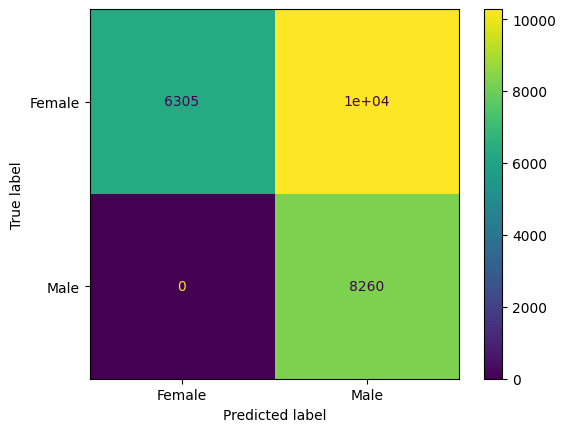

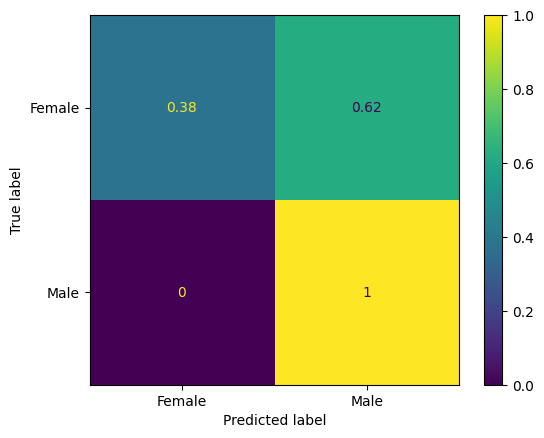

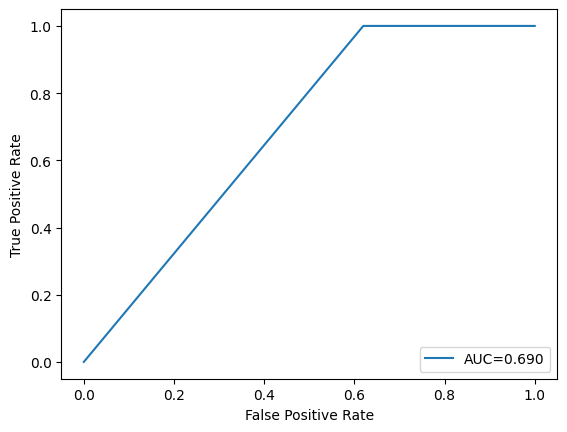

Test = Accuracy: 0.5862582514892932
Test - AUC: 0.690092860588519
Test - Balanced Accuracy: 0.690092860588519
All - KNN Classifier - wrong predictions:
------------------------
A03     2183
A06     1966
A05     1722
none    1258
A02     1149
A04     1008
A01      993
Name: count, dtype: int64
------------------------
A01     2723
A04     2708
A02     2567
A05     1994
A06     1750
A03     1533
none    1290
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A03 - 0.587% from total A03 values
wrong predictions by attack type:A06 - 0.529% from total A06 values
wrong predictions by attack type:none - 0.494% from total none values
wrong predictions by attack type:A05 - 0.463% from total A05 values
wrong predictions by attack type:A02 - 0.309% from total A02 values
wrong predictions by attack type:A04 - 0.271% from total A04 values
wrong predictions by attack type:A01 - 0.267% from total A01 values


In [27]:
check_performance(models_path+"gender_knn_model_both_norm_male_vs_female_db_models.pkl","KNN",validation_dataset)


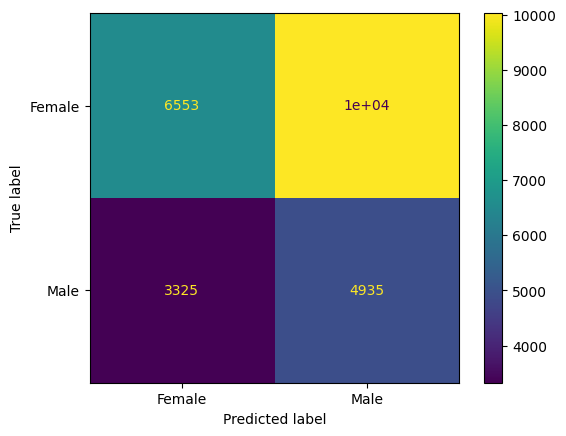

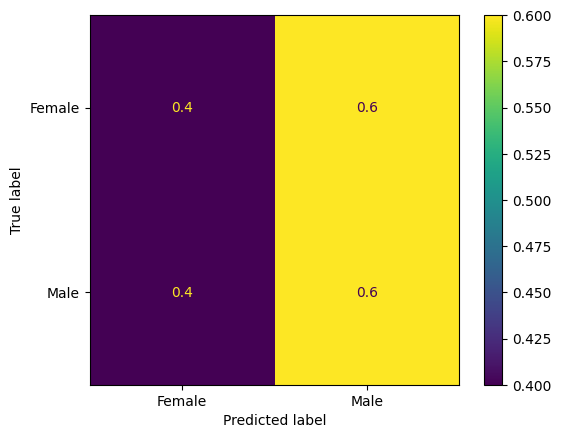

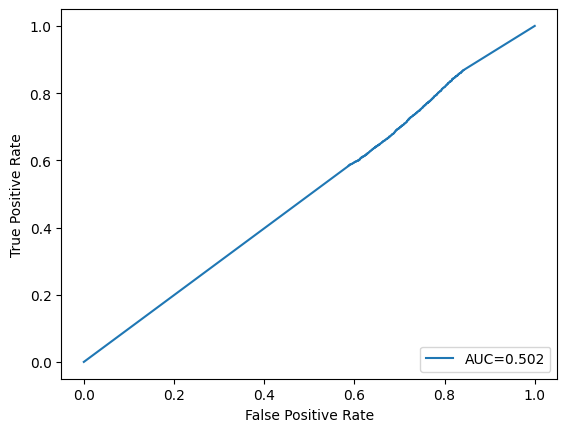

Test = Accuracy: 0.46240540975688293
Test - AUC: 0.5019699440459546
Test - Balanced Accuracy: 0.4962987604961286
All - Logistic Regression Classifier - wrong predictions:
------------------------
A02     2703
A06     2393
A01     1897
A05     1837
A04     1706
none    1617
A03     1203
Name: count, dtype: int64
------------------------
A03     2513
A04     2010
A05     1879
A01     1819
A06     1323
A02     1013
none     931
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A02 - 0.727% from total A02 values
wrong predictions by attack type:A06 - 0.644% from total A06 values
wrong predictions by attack type:none - 0.635% from total none values
wrong predictions by attack type:A01 - 0.510% from total A01 values
wrong predictions by attack type:A05 - 0.494% from total A05 values
wrong predictions by attack type:A04 - 0.459% from total A04 values
wrong predictions by attack type:A03 - 0.324% from total A03 values


In [28]:
check_performance(models_path+"gender_lr_model_both_norm_male_vs_female_db_models.pkl","Logistic Regression",validation_dataset)


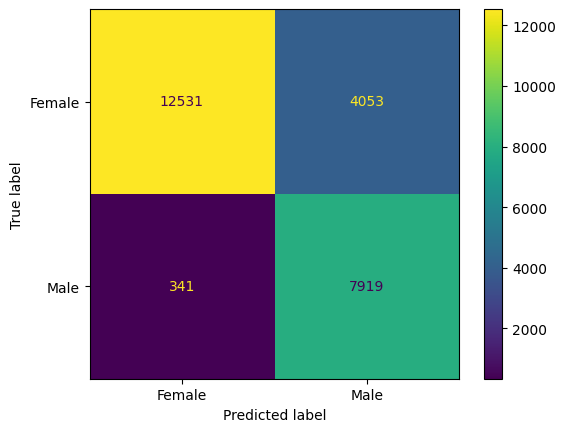

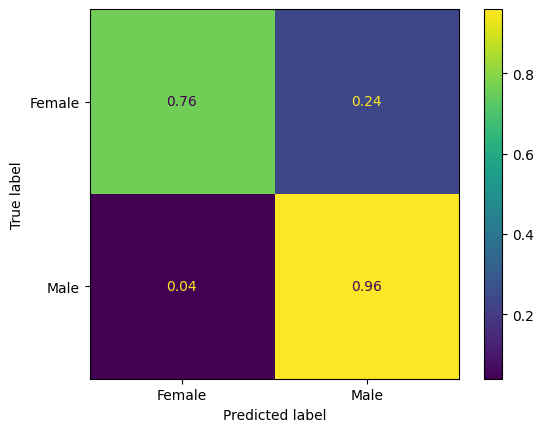

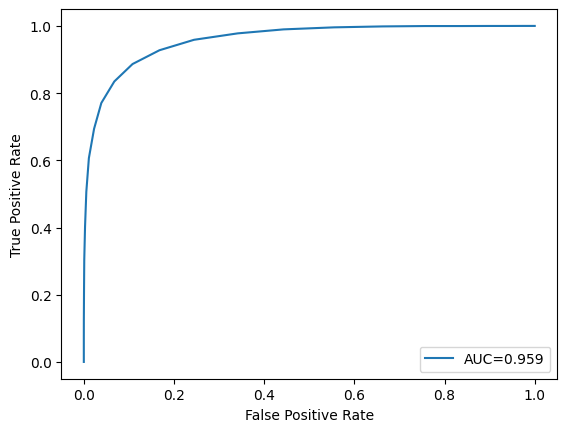

Test = Accuracy: 0.8231363709547577
Test - AUC: 0.9585129713110685
Test - Balanced Accuracy: 0.8571622608915037
All - Random Forest Classifier - wrong predictions:
------------------------
A03     1072
A05     1036
A02      643
none     553
A04      433
A01      413
A06      244
Name: count, dtype: int64
------------------------
A06     3472
A01     3303
A04     3283
A02     3073
A05     2680
A03     2644
none    1995
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A03 - 0.288% from total A03 values
wrong predictions by attack type:A05 - 0.279% from total A05 values
wrong predictions by attack type:none - 0.217% from total none values
wrong predictions by attack type:A02 - 0.173% from total A02 values
wrong predictions by attack type:A04 - 0.117% from total A04 values
wrong predictions by attack type:A01 - 0.111% from total A01 values
wrong predictions by attack type:A06 - 0.066% from total A06 values


In [29]:
check_performance(models_path+"gender_RFC_model_both_norm_male_vs_female_db_models.pkl","Random Forest",validation_dataset)


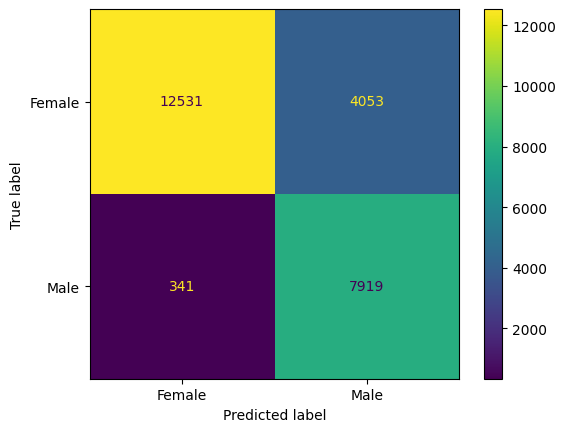

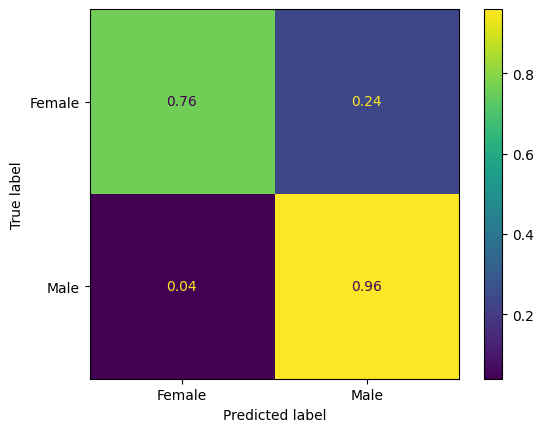

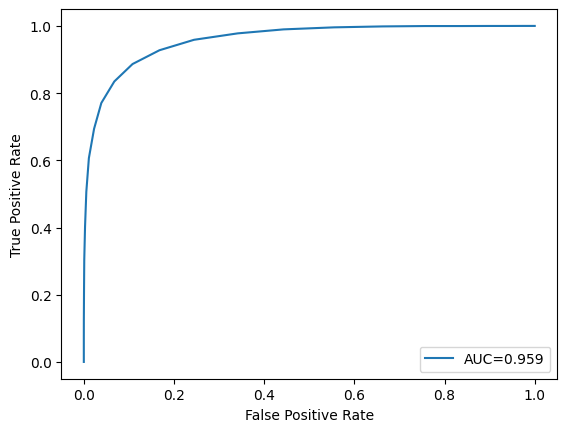

Test = Accuracy: 0.8231363709547577
Test - AUC: 0.9585129713110685
Test - Balanced Accuracy: 0.8571622608915037
All - XGB Classifier - wrong predictions:
------------------------
A03     1072
A05     1036
A02      643
none     553
A04      433
A01      413
A06      244
Name: count, dtype: int64
------------------------
A06     3472
A01     3303
A04     3283
A02     3073
A05     2680
A03     2644
none    1995
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A03 - 0.288% from total A03 values
wrong predictions by attack type:A05 - 0.279% from total A05 values
wrong predictions by attack type:none - 0.217% from total none values
wrong predictions by attack type:A02 - 0.173% from total A02 values
wrong predictions by attack type:A04 - 0.117% from total A04 values
wrong predictions by attack type:A01 - 0.111% from total A01 values
wrong predictions by attack type:A06 - 0.066% from total A06 values


In [30]:
check_performance(models_path+"gender_RFC_model_both_norm_male_vs_female_db_models.pkl","XGB",validation_dataset)

## Performance on Evaluation Set

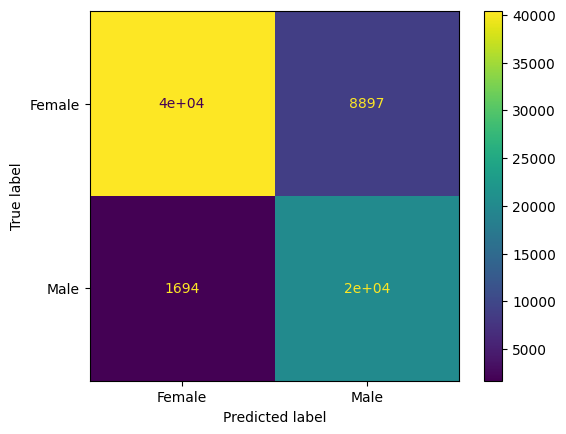

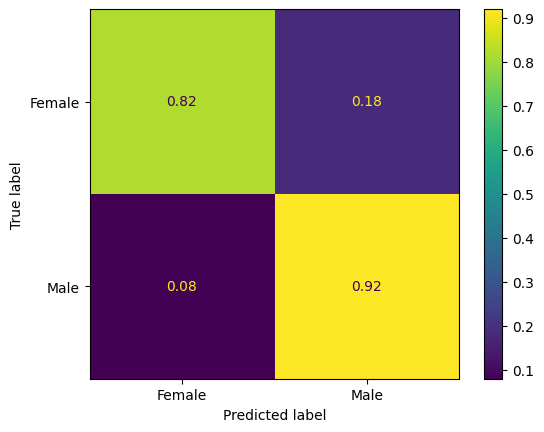

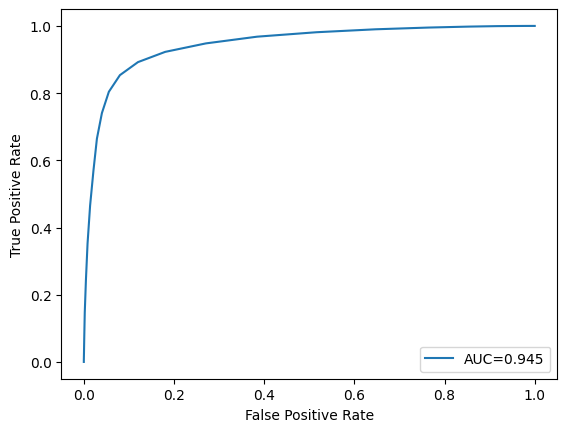

Test = Accuracy: 0.8513272597105437
Test - AUC: 0.9448063676962701
Test - Balanced Accuracy: 0.8711560267410656
All - Balanced Random Forest Classifier - wrong predictions:
------------------------
A08     1065
A18     1000
none     957
A13      938
A12      882
A11      803
A16      797
A10      779
A15      636
A19      611
A14      596
A07      553
A17      531
A09      443
Name: count, dtype: int64
------------------------
none    6398
A09     4471
A17     4383
A07     4361
A14     4318
A19     4303
A15     4278
A10     4135
A16     4117
A11     4111
A12     4032
A13     3976
A18     3914
A08     3849
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A08 - 0.217% from total A08 values
wrong predictions by attack type:A18 - 0.204% from total A18 values
wrong predictions by attack type:A13 - 0.191% from total A13 values
wrong predictions by attack type:A12 - 0.179% from total A12 values
wrong predictions by attack type:A11 - 0.163% from total A11 val

In [31]:
check_performance(models_path+"gender_BalancedRandomForest_model_both_norm_male_vs_female_db_models.pkl","Balanced Random Forest",test_dataset)

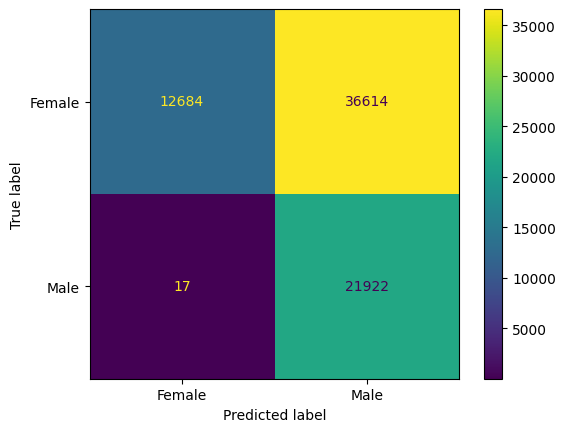

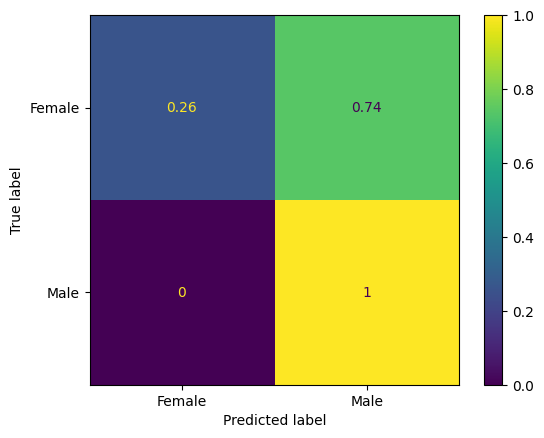

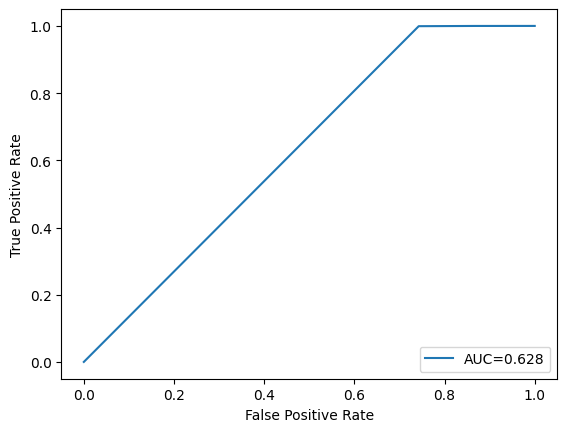

Test = Accuracy: 0.4857868804132684
Test - AUC: 0.6282987398972915
Test - Balanced Accuracy: 0.6282587546473237
All - KNN Classifier - wrong predictions:
------------------------
none    3718
A10     3014
A11     2987
A14     2953
A18     2911
A19     2886
A12     2856
A15     2824
A13     2400
A07     2323
A17     2193
A16     2040
A08     1862
A09     1664
Name: count, dtype: int64
------------------------
none    3637
A09     3250
A08     3052
A16     2874
A17     2721
A07     2591
A13     2514
A15     2090
A12     2058
A19     2028
A18     2003
A14     1961
A11     1927
A10     1900
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A10 - 0.613% from total A10 values
wrong predictions by attack type:A11 - 0.608% from total A11 values
wrong predictions by attack type:A14 - 0.601% from total A14 values
wrong predictions by attack type:A18 - 0.592% from total A18 values
wrong predictions by attack type:A19 - 0.587% from total A19 values
wrong predictio

In [32]:
check_performance(models_path+"gender_knn_model_both_norm_male_vs_female_db_models.pkl","KNN",test_dataset)

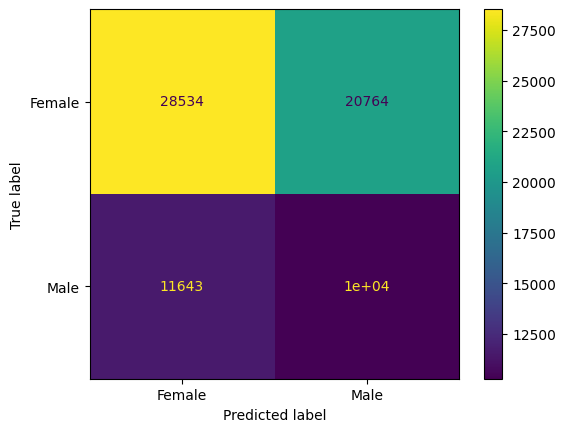

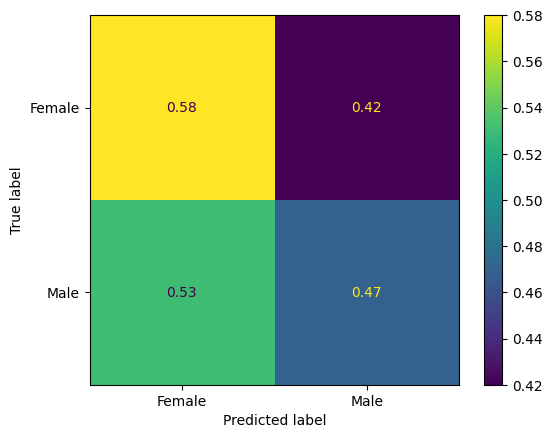

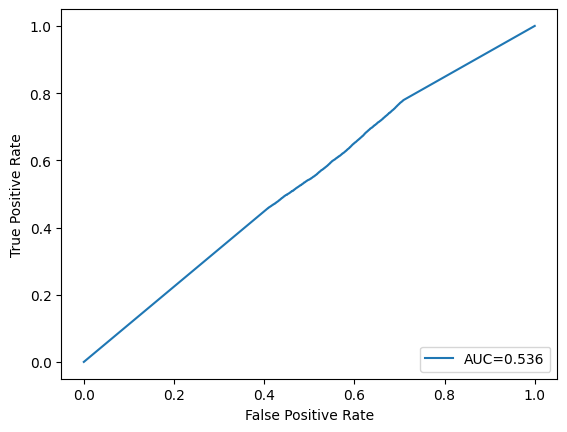

Test = Accuracy: 0.5450819096817665
Test - AUC: 0.5356149659788543
Test - Balanced Accuracy: 0.5240538434056933
All - Logistic Regression Classifier - wrong predictions:
------------------------
none    4288
A18     3287
A15     3072
A17     3014
A19     2823
A08     2348
A14     2315
A16     1762
A10     1759
A07     1755
A12     1525
A11     1513
A13     1482
A09     1464
Name: count, dtype: int64
------------------------
A09     3450
A13     3432
A11     3401
A12     3389
A07     3159
A10     3155
A16     3152
none    3067
A14     2599
A08     2566
A19     2091
A17     1900
A15     1842
A18     1627
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A18 - 0.669% from total A18 values
wrong predictions by attack type:A15 - 0.625% from total A15 values
wrong predictions by attack type:A17 - 0.613% from total A17 values
wrong predictions by attack type:none - 0.583% from total none values
wrong predictions by attack type:A19 - 0.574% from total A19 valu

In [33]:
check_performance(models_path+"gender_lr_model_both_norm_male_vs_female_db_models.pkl","Logistic Regression",test_dataset)

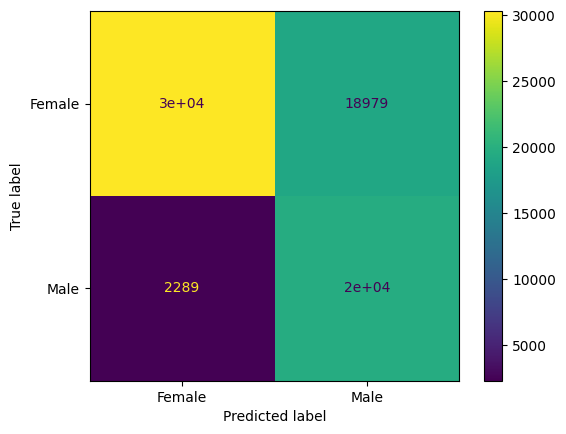

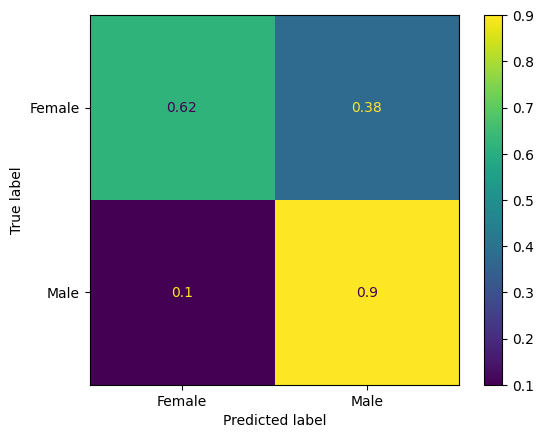

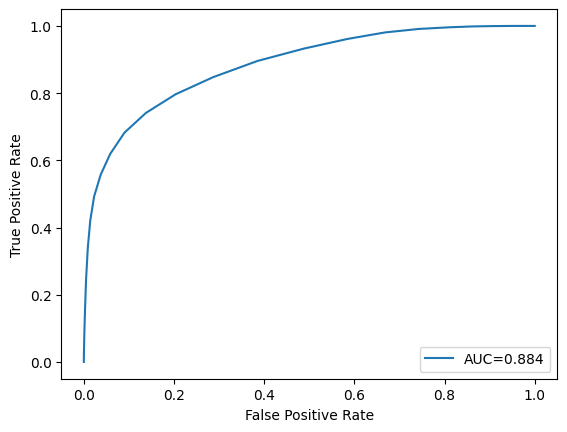

Test = Accuracy: 0.701447281609276
Test - AUC: 0.8838325127406963
Test - Balanced Accuracy: 0.7553400307804135
All - Random Forest Classifier - wrong predictions:
------------------------
A12     2112
none    2073
A11     1939
A18     1890
A10     1856
A17     1832
A14     1730
A13     1615
A15     1504
A08     1139
A07     1132
A16      928
A19      813
A09      705
Name: count, dtype: int64
------------------------
none    5282
A09     4209
A19     4101
A16     3986
A07     3782
A08     3775
A15     3410
A13     3299
A14     3184
A17     3082
A10     3058
A18     3024
A11     2975
A12     2802
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A12 - 0.430% from total A12 values
wrong predictions by attack type:A11 - 0.395% from total A11 values
wrong predictions by attack type:A18 - 0.385% from total A18 values
wrong predictions by attack type:A10 - 0.378% from total A10 values
wrong predictions by attack type:A17 - 0.373% from total A17 values
wrong 

In [34]:
check_performance(models_path+"gender_RFC_model_both_norm_male_vs_female_db_models.pkl","Random Forest",test_dataset)

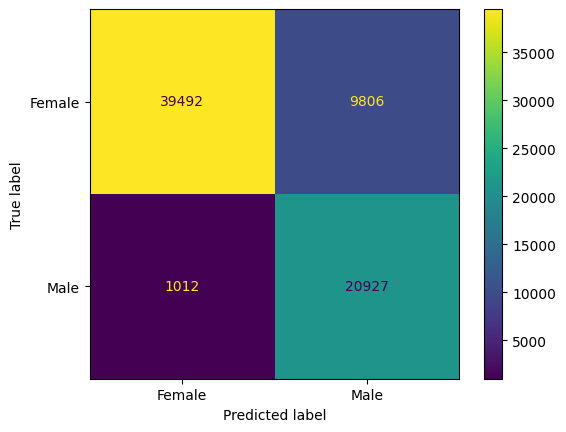

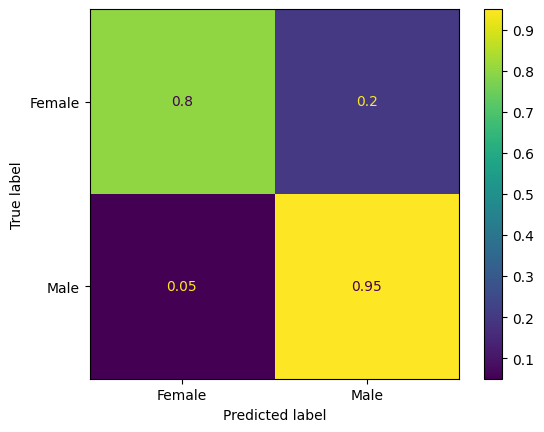

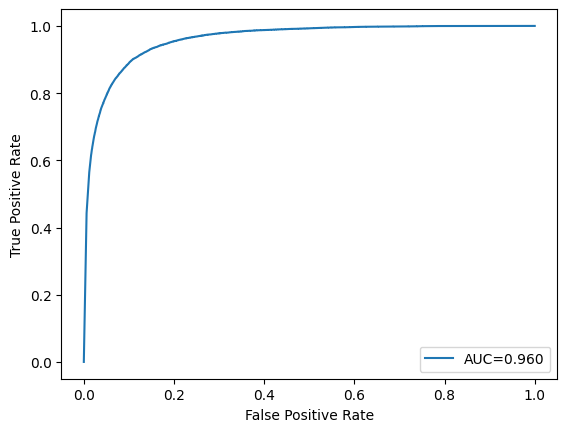

Test = Accuracy: 0.8481407133933209
Test - AUC: 0.959814434525823
Test - Balanced Accuracy: 0.8774796825584263
All - XGB Classifier - wrong predictions:
------------------------
A18     1709
none    1360
A17     1099
A19     1008
A14      767
A08      725
A16      720
A15      673
A10      623
A07      617
A12      492
A13      484
A11      349
A09      192
Name: count, dtype: int64
------------------------
none    5995
A09     4722
A11     4565
A13     4430
A12     4422
A07     4297
A10     4291
A15     4241
A16     4194
A08     4189
A14     4147
A19     3906
A17     3815
A18     3205
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A18 - 0.348% from total A18 values
wrong predictions by attack type:A17 - 0.224% from total A17 values
wrong predictions by attack type:A19 - 0.205% from total A19 values
wrong predictions by attack type:none - 0.185% from total none values
wrong predictions by attack type:A14 - 0.156% from total A14 values
wrong predicti

In [35]:
check_performance(models_path+"gender_XGB_model_both_norm_male_vs_female_db_models.pkl","XGB",test_dataset)

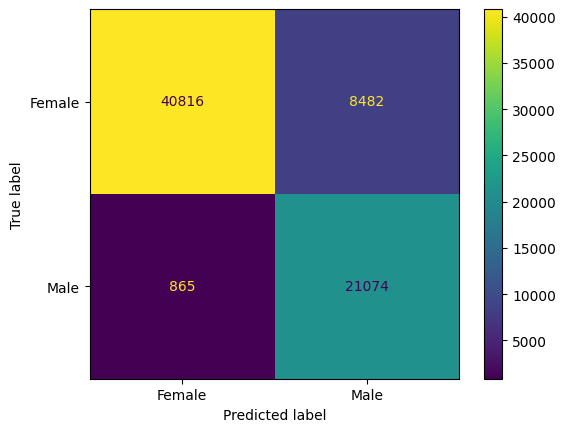

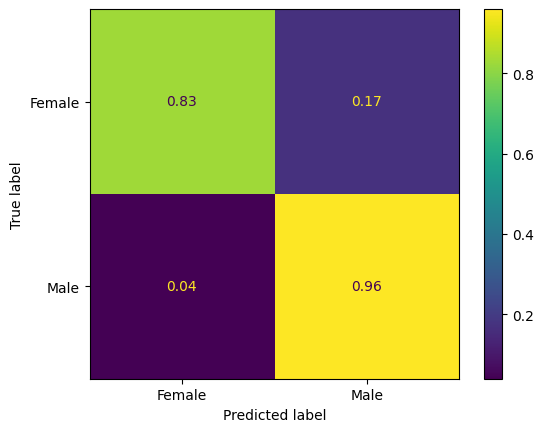

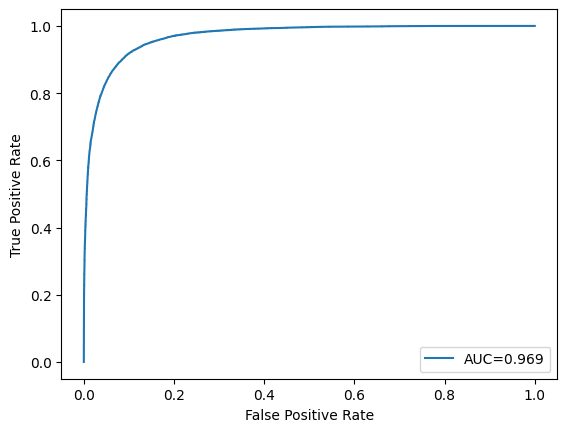

Test = Accuracy: 0.8687900950348836
Test - AUC: 0.9690539314368557
Test - Balanced Accuracy: 0.8942584174900983
All - RUSBoost Classifier - wrong predictions:
------------------------
A18     1516
none    1250
A17      911
A19      837
A14      683
A08      661
A16      612
A15      551
A10      525
A12      455
A13      437
A07      435
A11      292
A09      182
Name: count, dtype: int64
------------------------
none    6105
A09     4732
A11     4622
A07     4479
A13     4477
A12     4459
A10     4389
A15     4363
A16     4302
A08     4253
A14     4231
A19     4077
A17     4003
A18     3398
Name: count, dtype: int64
------------------------
wrong predictions by attack type:A18 - 0.309% from total A18 values
wrong predictions by attack type:A17 - 0.185% from total A17 values
wrong predictions by attack type:A19 - 0.170% from total A19 values
wrong predictions by attack type:none - 0.170% from total none values
wrong predictions by attack type:A14 - 0.139% from total A14 values
wrong pr

In [36]:
check_performance(models_path+"gender_RUSBoost_model_both_norm_male_vs_female_db_models.pkl","RUSBoost",test_dataset)